In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'   # 맥이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\07_카드_시간대_기상.csv', encoding='utf-8-sig', dtype={'일자': str})
df['일자'] = pd.to_datetime(df['일자'], format='%Y%m%d')
df['총결제금액'] = df['개인_결제금액'].fillna(0) + df['법인_결제금액'].fillna(0)

# 신적설 결측이 '눈 안 옴'인지 확인용
print('신적설최대_cm 결측 비율:', round(df['신적설최대_cm'].isna().mean() * 100, 1), '%')

# 시간대·업종을 합쳐서 '지역 × 일자' 한 행으로
daily = (df.groupby(['시군구', '일자'])
           .agg(총결제금액=('총결제금액', 'sum'),
                최고기온=('기온최고', 'max'),
                신적설=('신적설최대_cm', 'max'),
                한파특보=('한파_특보', 'max'),
                대설특보=('대설_특보', 'max'),
                폭염특보=('폭염_특보', 'max'),
                호우특보=('호우_특보', 'max'),
                요일=('요일', 'first'),
                휴일=('휴일', 'first'))
           .reset_index())

daily['영하일'] = (daily['최고기온'] < 0).astype(int)
daily['적설일'] = (daily['신적설'].fillna(0) > 0).astype(int)
daily['월'] = daily['일자'].dt.month

기후목록 = {'한파특보': '한파(특보)', '영하일': '영하(최고기온<0)',
           '대설특보': '대설(특보)', '적설일': '적설(신적설>0)',
           '폭염특보': '폭염(특보)', '호우특보': '호우(특보)'}

C:\Users\seoyeon\AppData\Local\Temp\ipykernel_10864\3186847074.py:8: DtypeWarning: Columns (0: 공휴일명) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\07_카드_시간대_기상.csv', encoding='utf-8-sig', dtype={'일자': str})


신적설최대_cm 결측 비율: 50.2 %


In [2]:
이벤트일수 = (daily.groupby('시군구')[list(기후목록)].sum()
                 .rename(columns=기후목록).T)
이벤트일수.index.name = '기후'
print(이벤트일수)

시군구         강원 춘천시  서울 강남구
기후                        
한파(특보)           8       4
영하(최고기온<0)       4       3
대설(특보)           3       1
적설(신적설>0)       15       4
폭염(특보)          40      40
호우(특보)           9       9


### 1단계: 기준매출 구하기

기준매출은 날씨 이벤트가 없었다면 그날 평소에 얼마쯤 팔렸을지를 잡은 값이에요.

- 같은 지역, 같은 월, 같은 요일의 날들 중에서
- 기후 이벤트가 없고 휴일도 아닌 날(평상일)만 골라
- 그날들의 일 매출을 평균 낸 값이에요.

예를 들어 춘천의 12월 월요일 평상일이 12/1, 12/8, 12/22라면:

> 기준매출 = (12/1 매출 + 12/8 매출 + 12/22 매출) ÷ 3

### 2단계: 매출지수 구하기 (이벤트일마다)

> 매출지수 = 그날 실제 매출 ÷ 그날의 기준매출

- 1.0이면 평소와 같아요.
- 1.2이면 평소보다 20% 더 팔렸다는 뜻이에요.
- 0.9이면 평소보다 10% 덜 팔렸다는 뜻이에요.

### 3단계: 평균변화율 구하기

> 평균변화율(%) = (이벤트일들의 매출지수 평균 − 1) × 100

            기후     시군구  이벤트일수  기준선없는일수  휴일포함일수  평균변화율(%)
0       한파(특보)  강원 춘천시      8        1       2      28.0
1       한파(특보)  서울 강남구      4        1       2      -4.1
2   영하(최고기온<0)  강원 춘천시      4        1       1      23.5
3   영하(최고기온<0)  서울 강남구      3        0       0       4.7
4       대설(특보)  강원 춘천시      3        1       1       4.4
5       대설(특보)  서울 강남구      1        0       0      53.2
6    적설(신적설>0)  강원 춘천시     15        5       6      31.4
7    적설(신적설>0)  서울 강남구      4        2       2      17.6
8       폭염(특보)  강원 춘천시     40       15      13       8.9
9       폭염(특보)  서울 강남구     40       15      13      16.7
10      호우(특보)  강원 춘천시      9        4       2      17.7
11      호우(특보)  서울 강남구      9        3       2      -8.0
시군구         강원 춘천시  서울 강남구
기후                        
대설(특보)         4.4    53.2
영하(최고기온<0)    23.5     4.7
적설(신적설>0)     31.4    17.6
폭염(특보)         8.9    16.7
한파(특보)        28.0    -4.1
호우(특보)        17.7    -8.0


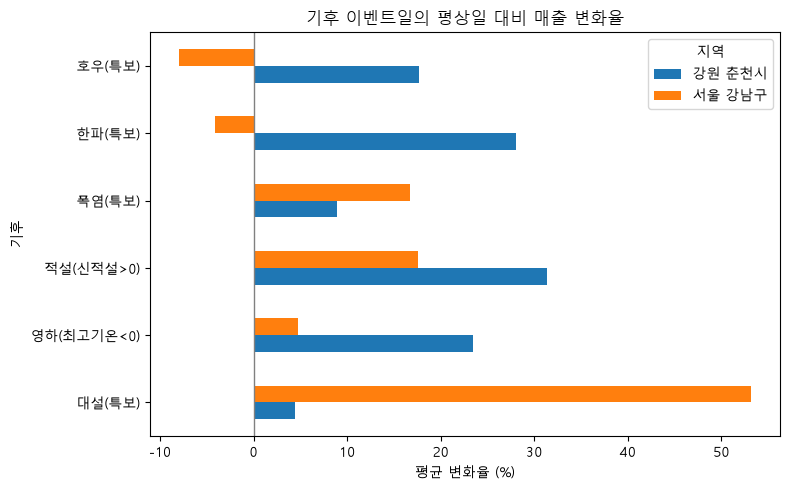

In [3]:
# 기준선: 같은 지역·같은 월·같은 요일의 평상일(기후 이벤트 없음 + 휴일 아님) 평균
daily['이벤트있음'] = daily[list(기후목록)].max(axis=1)
평상일 = daily[(daily['이벤트있음'] == 0) & (daily['휴일'] == 'N')]
기준선 = (평상일.groupby(['시군구', '월', '요일'])['총결제금액']
              .mean().rename('기준매출').reset_index())

daily = daily.merge(기준선, on=['시군구', '월', '요일'], how='left')
daily['매출지수'] = daily['총결제금액'] / daily['기준매출']

rows = []
for col, 이름 in 기후목록.items():
    for 지역, g in daily[daily[col] == 1].groupby('시군구'):
        rows.append({'기후': 이름, '시군구': 지역,
                     '이벤트일수': len(g),
                     '기준선없는일수': g['기준매출'].isna().sum(),
                     '휴일포함일수': (g['휴일'] == 'Y').sum(),
                     '평균변화율(%)': round((g['매출지수'].mean() - 1) * 100, 1)})
변화율 = pd.DataFrame(rows)
print(변화율)

# 지역 나란히 비교
비교표 = 변화율.pivot(index='기후', columns='시군구', values='평균변화율(%)')
print(비교표)

비교표.plot(kind='barh', figsize=(8, 5))
plt.axvline(0, color='gray', lw=1)
plt.title('기후 이벤트일의 평상일 대비 매출 변화율')
plt.xlabel('평균 변화율 (%)')
plt.ylabel('기후')
plt.legend(title='지역')
plt.tight_layout()
plt.show()

# 일별 요약본 저장 (원본은 그대로 둠)
daily.to_csv('07_일별_기후이벤트_요약.csv', index=False, encoding='utf-8-sig')

In [4]:
# 기준선: 같은 지역·같은 요일, 해당일 ±14일 이내 평상일 평균 (월 경계 문제 해소)
평상일 = daily[(daily['이벤트있음'] == 0) & (daily['휴일'] == 'N')]

def 기준선_계산(row):
    후보 = 평상일[(평상일['시군구'] == row['시군구']) &
                 (평상일['요일'] == row['요일']) &
                 ((평상일['일자'] - row['일자']).abs() <= pd.Timedelta(days=14))]
    return pd.Series({'기준매출2': 후보['총결제금액'].mean(), '기준일수': len(후보)})

daily[['기준매출2', '기준일수']] = daily.apply(기준선_계산, axis=1)
daily['매출지수2'] = daily['총결제금액'] / daily['기준매출2']

rows = []
for col, 이름 in 기후목록.items():
    대상 = daily[(daily[col] == 1) & (daily['휴일'] == 'N')]   # 이벤트일에서도 휴일 제외
    for 지역, g in 대상.groupby('시군구'):
        rows.append({'기후': 이름, '시군구': 지역,
                     '평일이벤트일수': len(g),
                     '평균기준일수': round(g['기준일수'].mean(), 1),
                     '평균변화율(%)': round((g['매출지수2'].mean() - 1) * 100, 1),
                     '중앙값변화율(%)': round((g['매출지수2'].median() - 1) * 100, 1)})
변화율2 = pd.DataFrame(rows)
print(변화율2)

            기후     시군구  평일이벤트일수  평균기준일수  평균변화율(%)  중앙값변화율(%)
0       한파(특보)  강원 춘천시        6     2.0      -8.5      -26.4
1       한파(특보)  서울 강남구        2     2.0      26.8       26.8
2   영하(최고기온<0)  강원 춘천시        3     1.7       9.5        9.5
3   영하(최고기온<0)  서울 강남구        3     2.7       9.3       26.7
4       대설(특보)  강원 춘천시        2     2.5      -4.3       -4.3
5       대설(특보)  서울 강남구        1     4.0      30.1       30.1
6    적설(신적설>0)  강원 춘천시        9     2.0      34.3       20.6
7    적설(신적설>0)  서울 강남구        2     4.0      -0.6       -0.6
8       폭염(특보)  강원 춘천시       27     1.4       7.4        8.0
9       폭염(특보)  서울 강남구       27     1.3      17.6        4.3
10      호우(특보)  강원 춘천시        7     1.1      17.2       -5.9
11      호우(특보)  서울 강남구        7     1.4      -5.4       -1.4


In [5]:
# 폭염 에피소드 구분: 연속된 폭염특보일을 하나의 에피소드로 묶음
ep = daily[['시군구', '일자', '폭염특보', '호우특보']].sort_values(['시군구', '일자']).copy()

def 에피소드_요약(g, col):
    g = g.copy()
    g['새구간'] = (g[col] != g[col].shift()).cumsum()
    구간 = (g[g[col] == 1].groupby('새구간')['일자']
            .agg(시작일='min', 종료일='max', 지속일수='count').reset_index(drop=True))
    구간['다음까지간격(일)'] = (구간['시작일'].shift(-1) - 구간['종료일']).dt.days - 1
    return 구간

for 기후 in ['폭염특보', '호우특보']:
    print(f'===== {기후} =====')
    for 지역, g in ep.groupby('시군구'):
        print(f'--- {지역} ---')
        print(에피소드_요약(g, 기후))

===== 폭염특보 =====
--- 강원 춘천시 ---
         시작일        종료일  지속일수  다음까지간격(일)
0 2025-07-07 2025-07-13     7        7.0
1 2025-07-21 2025-08-06    17        8.0
2 2025-08-15 2025-08-25    11        1.0
3 2025-08-27 2025-08-31     5        NaN
--- 서울 강남구 ---
         시작일        종료일  지속일수  다음까지간격(일)
0 2025-07-07 2025-07-13     7        7.0
1 2025-07-21 2025-08-06    17        8.0
2 2025-08-15 2025-08-25    11        1.0
3 2025-08-27 2025-08-31     5        NaN
===== 호우특보 =====
--- 강원 춘천시 ---
         시작일        종료일  지속일수  다음까지간격(일)
0 2025-07-16 2025-07-18     3        1.0
1 2025-07-20 2025-07-20     1       16.0
2 2025-08-06 2025-08-06     1        6.0
3 2025-08-13 2025-08-14     2       29.0
4 2025-09-13 2025-09-13     1        3.0
5 2025-09-17 2025-09-17     1        NaN
--- 서울 강남구 ---
         시작일        종료일  지속일수  다음까지간격(일)
0 2025-07-16 2025-07-19     4       24.0
1 2025-08-13 2025-08-14     2       17.0
2 2025-09-01 2025-09-01     1       11.0
3 2025-09-13 2025-09-13     1        3.0
4 20

Note: you may need to restart the kernel to use updated packages.


C:\Users\seoyeon\AppData\Local\Temp\ipykernel_10864\1123469126.py:11: DtypeWarning: Columns (0: 공휴일명) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\07_카드_시간대_기상.csv', encoding='utf-8-sig', dtype={'일자': str})


빠진 날짜 수(지역별):
시군구
강원 춘천시    0
서울 강남구    0
Name: 폭염, dtype: int64


c:\Users\seoyeon\.conda\envs\myenv\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 21 singleton fixed effect(s) dropped from the model.
  warnings.warn(


관측치 수: 28479
기후  시점  시점(일)  일별효과(%)  일별_p값  누적효과(하루매출대비 %)  누적_하한  누적_상한
폭염 전3일     -3     1.13  0.678            1.12  -4.15   6.39
폭염 전2일     -2     1.23  0.683            2.34  -3.21   7.89
폭염 전1일     -1     2.17  0.579            4.49  -2.64  11.61
폭염  당일      0     7.54  0.108           11.76   2.77  20.75
폭염 후1일      1    -5.32  0.184            6.29  -2.13  14.72
폭염 후2일      2    -3.03  0.424            3.22  -5.21  11.65
폭염 후3일      3     3.15  0.418            6.32  -2.18  14.83
폭염 후4일      4    -2.41  0.418            3.89  -5.57  13.34
폭염 후5일      5    -1.62  0.606            2.25  -7.45  11.95
폭염 후6일      6     2.26  0.584            4.48  -6.65  15.62
폭염 후7일      7     3.08  0.315            7.51  -3.70  18.73
호우 전3일     -3    -1.09  0.778           -1.10  -8.73   6.54
호우 전2일     -2     1.47  0.718            0.36  -9.95  10.67
호우 전1일     -1    -5.80  0.098           -5.61 -17.73   6.50
호우  당일      0   -10.19  0.001          -16.36 -29.83  -2.89
호우 후1일      1     5.42  0.1

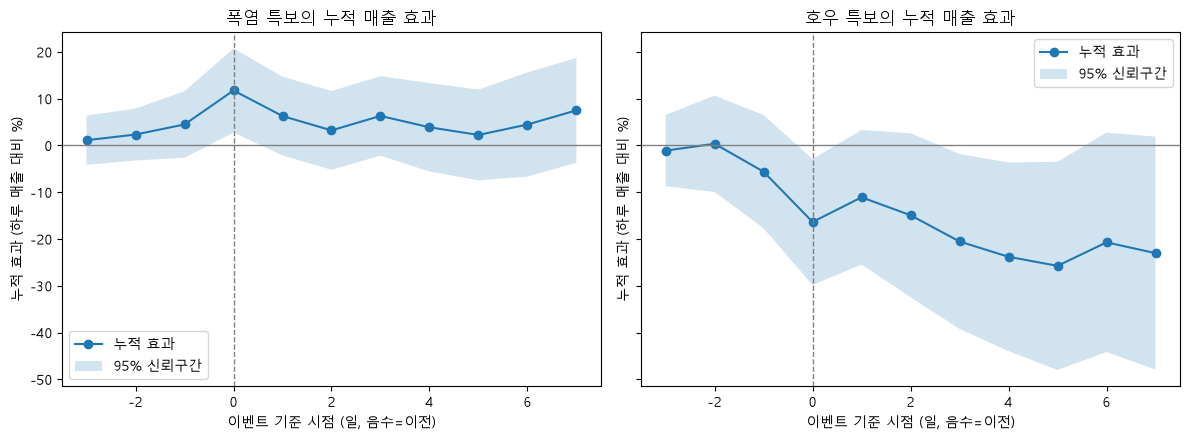

In [13]:
%pip install -q pyfixest

import pandas as pd
import numpy as np
import pyfixest as pf
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv(r'C:\DI\[공모전] 14회 빅콘테스트\새 데이터 셋\07_카드_시간대_기상.csv', encoding='utf-8-sig', dtype={'일자': str})
df['일자'] = pd.to_datetime(df['일자'], format='%Y%m%d')
df['총결제금액'] = df['개인_결제금액'].fillna(0) + df['법인_결제금액'].fillna(0)

# ── 1. 분석 단위: 지역 × 업종 × 일자 (시간대는 합침) ──
업종일 = (df.groupby(['시군구', '카드업종', '일자'])['총결제금액']
            .sum().reset_index())

# ── 2. 날씨: 지역 × 일자, 달력상 빠진 날 없이 정렬 ──
날씨 = (df.groupby(['시군구', '일자'])
          .agg(폭염=('폭염_특보', 'max'), 호우=('호우_특보', 'max'),
               요일=('요일', 'first'), 휴일=('휴일', 'first'))
          .reset_index())

전체날짜 = pd.date_range(날씨['일자'].min(), 날씨['일자'].max(), freq='D')
전체키 = pd.MultiIndex.from_product([날씨['시군구'].unique(), 전체날짜], names=['시군구', '일자'])
날씨 = (날씨.set_index(['시군구', '일자'])
          .reindex(전체키)
          .reset_index()
          .sort_values(['시군구', '일자'])
          .reset_index(drop=True))

print('빠진 날짜 수(지역별):')
print(날씨.groupby('시군구')['폭염'].apply(lambda s: s.isna().sum()))

# ── 3. 시차 변수: 후k일 = k일 전에 이벤트가 있었음(회복), 전k일 = k일 뒤에 이벤트가 옴(선구매) ──
시차목록 = [('전3일', -3), ('전2일', -2), ('전1일', -1), ('당일', 0)] + [(f'후{k}일', k) for k in range(1, 8)]
for 기후 in ['폭염', '호우']:
    for 이름, k in 시차목록:
        날씨[f'{기후}_{이름}'] = 날씨.groupby('시군구')[기후].shift(k)

# ── 4. 합치기 + 모형용 변수 ──
모형df = 업종일.merge(날씨.drop(columns=['폭염', '호우']), on=['시군구', '일자'], how='left')
모형df = 모형df.dropna(subset=[c for c in 모형df.columns if c.startswith(('폭염_', '호우_'))])  # 기간 앞뒤 끝부분 제외
모형df['로그매출'] = np.log1p(모형df['총결제금액'])
모형df['휴일여부'] = (모형df['휴일'] == 'Y').astype(int)
모형df['월'] = 모형df['일자'].dt.month
모형df['그룹_월'] = 모형df['시군구'] + '_' + 모형df['카드업종'] + '_' + 모형df['월'].astype(str)
모형df['그룹_요일'] = 모형df['시군구'] + '_' + 모형df['카드업종'] + '_' + 모형df['요일']
모형df['일자키'] = 모형df['일자'].dt.strftime('%Y%m%d')

모형df.to_csv('08_회귀모형용_업종일별.csv', index=False, encoding='utf-8-sig')

# ── 5. 회귀 (표준오차는 날짜 단위로 군집) ──
설명변수 = [f'{기후}_{이름}' for 기후 in ['폭염', '호우'] for 이름, _ in 시차목록]
식 = '로그매출 ~ ' + ' + '.join(설명변수) + ' + 휴일여부 | 그룹_월 + 그룹_요일'
모형 = pf.feols(식, data=모형df, vcov={'CRV1': '일자키'})
print('관측치 수:', 모형._N)

# ── 6. 일별 효과 + 누적 효과 ──
계수 = 모형.coef()
공분산 = pd.DataFrame(모형._vcov, index=계수.index, columns=계수.index)

rows = []
for 기후 in ['폭염', '호우']:
    누적변수 = []
    for 이름, k in 시차목록:
        v = f'{기후}_{이름}'
        누적변수.append(v)
        b = 계수[v]
        se = np.sqrt(공분산.loc[v, v])
        누적b = 계수[누적변수].sum()
        누적se = np.sqrt(공분산.loc[누적변수, 누적변수].values.sum())
        rows.append({'기후': 기후, '시점': 이름, '시점(일)': k,
                     '일별효과(%)': round((np.exp(b) - 1) * 100, 2),
                     '일별_p값': round(모형.pvalue()[v], 3),
                     '누적효과(하루매출대비 %)': round(누적b * 100, 2),
                     '누적_하한': round((누적b - 1.96 * 누적se) * 100, 2),
                     '누적_상한': round((누적b + 1.96 * 누적se) * 100, 2)})
결과 = pd.DataFrame(rows)
print(결과.to_string(index=False))

# ── 7. 누적 효과 그래프 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, 기후 in zip(axes, ['폭염', '호우']):
    g = 결과[결과['기후'] == 기후]
    ax.plot(g['시점(일)'], g['누적효과(하루매출대비 %)'], marker='o', label='누적 효과')
    ax.fill_between(g['시점(일)'], g['누적_하한'], g['누적_상한'], alpha=0.2, label='95% 신뢰구간')
    ax.axhline(0, color='gray', lw=1)
    ax.axvline(0, color='gray', lw=1, ls='--')
    ax.set_title(f'{기후} 특보의 누적 매출 효과')
    ax.set_xlabel('이벤트 기준 시점 (일, 음수=이전)')
    ax.set_ylabel('누적 효과 (하루 매출 대비 %)')
    ax.legend()
plt.tight_layout()
plt.show()